# AdaBoost from Scratch — A Hands-On Tutorial

*Chain hundreds of "barely-better-than-a-coin-flip" stumps into one sharp classifier — using only NumPy — by making each new stump obsess over the last one's mistakes.*

---

## Overview

This tutorial turns a compact `adaboost.py` script into a complete, visual learning experience. It is the **boosting** counterpart to the Random Forest notebook: where a forest builds many trees **in parallel** and averages them, **AdaBoost** builds weak learners **one after another**, each fixing its predecessors' errors.

- **What it teaches:** how **boosting** turns a **weak learner** (a one-split *decision stump*) into a strong classifier by **reweighting** the training data and taking a **weighted vote**.
- **Who it's for:** beginners and intermediate learners who understand a decision tree and want to see the other great ensemble idea — boosting.
- **ML task type:** **Classification** — here **binary** (AdaBoost's classic form), with labels internally treated as $\pm 1$.

### Learning outcomes
By the end you will be able to:
1. Explain a **weak learner** and why boosting many of them reduces **bias** (bagging reduces variance).
2. Describe the AdaBoost loop: **reweight** misclassified points, compute each learner's say **$\alpha$**, and **vote**.
3. Read a **training-error-per-round** learning curve and watch the boundary sharpen as rounds accumulate.
4. Evaluate with **accuracy, precision, recall, F1**, a **confusion matrix**, and **ROC-AUC**.

### What you will build
A from-scratch `AdaBoost` class (built on a from-scratch `DecisionStump`) that mirrors the sklearn API — `fit` / `predict` / `decision_function` — records per-round **errors, weights (α), and sample-weight history**, and drives charts including the **sample-reweighting** panels, the **boundary forming** animation, a **confusion matrix**, and interactive **rounds** explorers.

> **How to use this notebook (read me first)**
> - Run the cells **in order, top to bottom** — in VS Code click **▶▶ Run All**.
> - Every code cell is followed by a short **plain-English explanation**.
> - The **animations** have a ▶ play button — press it to watch the idea move.
> - Look for the **"Key insight"** lines: each is the single thing to remember from that chart.
> - Sections are numbered **1 → 16**; read the concept (1–2) first, then the code builds up step by step.


## 1. The concept in plain language

A **decision stump** is the world's simplest classifier: a decision tree with **one split** ("is feature $j \le t$?"). On its own it is a **weak learner** — barely better than a coin flip. **AdaBoost** ("Adaptive Boosting") combines many stumps into one strong model with a clever loop:

1. **Weight every training point equally** to start.
2. **Train a stump** that minimises the *weighted* error.
3. Give that stump a **say $\alpha$** based on how good it is (accurate stumps get a big vote; near-random ones get almost none).
4. **Reweight the data:** *increase* the weight of points the stump got **wrong**, so the next stump is forced to focus on them.
5. **Repeat** for many rounds, then predict by a **weighted vote** of all stumps.

$$\alpha_t = \tfrac{1}{2}\ln\!\frac{1-\varepsilon_t}{\varepsilon_t}, \qquad \hat{y}(x) = \operatorname{sign}\!\Big(\sum_t \alpha_t\, h_t(x)\Big)$$

where $\varepsilon_t$ is the weighted error of stump $h_t$. A stump with error near 0 gets a **large** $\alpha$; one near 0.5 (a coin flip) gets $\alpha \approx 0$.

### Boosting vs bagging (how it differs from a random forest)
- **Random forest (bagging):** many **independent** deep trees, trained in parallel on bootstrap samples, then **averaged** → reduces **variance**.
- **AdaBoost (boosting):** many **dependent, shallow** stumps, trained **sequentially**, each targeting the last one's mistakes, then **weighted-voted** → reduces **bias** (turns weak learners strong).

### Everyday examples
Boosting is a top performer on tabular data:

| Domain | Input features (x) | Predicted class (ŷ) |
|--------|--------------------|----------------------|
| Face detection | image features | face vs not-face (the classic Viola–Jones use) |
| Medicine | test measurements | disease vs healthy |
| Banking | account features | default vs repay |
| Ranking / search | query–document features | relevant vs not |
| Ad tech | user + context features | click vs no-click |
| Security | event features | intrusion vs normal |
| Churn | usage features | churn vs stay |

### Two simple analogies
1. **A study group that targets weak spots.** After each practice test, the group spends most time on the questions it got **wrong**. Over rounds, the blind spots shrink. Each stump is one study session focused on current mistakes.
2. **A panel where good judges get louder.** Every judge (stump) votes, but the **more reliable** ones are given a **bigger microphone** ($\alpha$). The verdict is their weighted consensus.

### Key terms
- **Weak learner / decision stump** — a one-split classifier, slightly better than chance.
- **Sample weights** — importance of each training point; grow on mistakes.
- **$\alpha$ (estimator weight)** — a stump's vote strength, from its weighted error.
- **Weighted vote** — final prediction = sign of the $\alpha$-weighted sum of stumps.
- **Round / estimator** — one iteration adding one stump.
- **Boosting** — sequentially combining weak learners to reduce bias.


### See it — each stump attacks the last one's mistakes

Before any model code, here is the whole idea in one picture. We run a few AdaBoost rounds on a simple 2-D set. Each frame shows the **current sample weights as dot sizes** (bigger = "pay attention to me") and the **stump** chosen that round (an axis-aligned cut). Watch the **misclassified points swell**, forcing the next stump to focus on them.

**Learning objective:** see boosting's engine — *reweight toward mistakes, round after round*. (Press ▶ to play.)


In [1]:
# Self-contained intuition demo (imports here so it runs even before Setup)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

rng = np.random.default_rng(1)
A = rng.normal([-1.5, 0], 1.0, size=(30, 2))
B = rng.normal([1.5, 0], 1.0, size=(30, 2))
Xd = np.vstack([A, B]); td = np.array([-1] * 30 + [1] * 30)

def best_stump(X, t, w):
    """Find the weighted-error-minimising 1-split stump (feature, threshold, polarity)."""
    n, d = X.shape
    best = dict(err=np.inf)
    for f in range(d):
        for thr in np.unique(X[:, f]):
            for p in (1, -1):
                pred = np.ones(n); pred[p * X[:, f] < p * thr] = -1
                err = w[pred != t].sum()
                if err < best["err"]:
                    best = dict(err=err, f=f, thr=thr, p=p, pred=pred)
    return best

w = np.full(len(Xd), 1 / len(Xd))
rounds = []
for _ in range(6):
    s = best_stump(Xd, td, w)
    eps = 1e-10
    alpha = 0.5 * np.log((1 - s["err"] + eps) / (s["err"] + eps))
    rounds.append((w.copy(), s, alpha))
    w = w * np.exp(-alpha * td * s["pred"]); w /= w.sum()

fig, ax = plt.subplots(figsize=(7, 6))
def draw(i):
    ax.clear()
    w_i, s, alpha = rounds[i]
    sizes = 20 + w_i / w_i.max() * 400
    ax.scatter(Xd[:, 0], Xd[:, 1], s=sizes, c=td, cmap="coolwarm",
               edgecolor="white", linewidth=0.5, alpha=0.85)
    if s["f"] == 0:
        ax.axvline(s["thr"], color="black", lw=2)
    else:
        ax.axhline(s["thr"], color="black", lw=2)
    ax.set_title(f"round {i+1}: stump on feature {s['f']}   "
                 f"weighted error={s['err']:.2f},  alpha={alpha:.2f}")
    ax.set_xlim(-5, 5); ax.set_ylim(-4, 4)
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")

ada_anim = animation.FuncAnimation(fig, draw, frames=len(rounds), interval=1100)
plt.close(fig)  # avoid a duplicate static figure
HTML(ada_anim.to_jshtml())


**What to notice:** points the current stump **misclassifies grow larger** each round — their weight rises so the next stump can't ignore them. A stump with low weighted error earns a **large $\alpha$** (a loud vote); a near-random one earns $\alpha\approx0$. The final classifier is the **$\alpha$-weighted vote** of all these focused stumps.


## 2. The machine-learning workflow

Almost every supervised-learning project follows the same path. Here is how this notebook maps onto it:

```mermaid
flowchart LR
    A[Load / generate data] --> B[Explore the data]
    B --> C[Train / test split]
    C --> D[Boost - reweight & add stumps]
    D --> E[Weighted-vote predictions]
    E --> F[Evaluate - accuracy, F1, ROC-AUC]
    F --> G[Visualise reweighting & boundary]
    G --> H[Tune rounds & learning rate]
```

| Step | What it means | Where in this notebook |
|------|---------------|------------------------|
| Data loading | Get labelled examples to learn from | Section 6 |
| Data exploration (EDA) | Look at shape, class balance, separation | Section 7 |
| Train/test split | Hold out data for honest evaluation | Section 6 |
| Model training | Sequentially add reweighted stumps | Section 8 |
| Prediction | Weighted vote of all stumps | Section 8 |
| Evaluation | accuracy, F1, ROC-AUC | Section 9 |
| Interpretation | Reweighting, boundary, α, feature use | Sections 10–12 |

**Note on feature scaling:** the base learner is a **decision stump** (a threshold test), so AdaBoost is **scale-invariant** — no `StandardScaler` needed (same as trees/forests). The knobs that matter are **`n_estimators`** (rounds) and the **`learning_rate`** (how strongly each stump's $\alpha$ counts). Too many rounds on **noisy** data can eventually **overfit** — we'll watch that happen.


## 3. Setup — import the tools

We use a small, standard stack:

- **NumPy** — the array math behind stumps, weights and voting.
- **pandas** — to hold the data as a table for quick exploration.
- **Matplotlib / seaborn** — for the charts and animations.
- **scikit-learn** — *only* to generate/load datasets and split them. **The stump and AdaBoost are written from scratch.**

> If a package is missing, install it once with:
> `pip install numpy pandas matplotlib seaborn scikit-learn plotly`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split

# Nicer default styling for all plots
sns.set_theme(style="whitegrid")
%matplotlib inline


## 4. Evaluation metrics (defined first so we can reuse them)

For **classification** we judge the model with a family of related numbers, all built from the **confusion matrix** $M$, where $M_{t,p}$ counts points with true class $t$ predicted as $p$.

$$\text{accuracy} = \frac{\text{correct}}{\text{total}} \qquad \text{precision}_c = \frac{TP_c}{TP_c+FP_c} \qquad \text{recall}_c = \frac{TP_c}{TP_c+FN_c}$$

$$F1_c = 2\cdot\frac{\text{precision}_c\cdot\text{recall}_c}{\text{precision}_c+\text{recall}_c}$$

- **Accuracy** — overall fraction correct (fair when classes are balanced).
- **Precision / Recall / F1** — computed **per class**, then **macro-averaged**.

> These work for **any number of classes**, with a tiny `eps` guarding the denominators.


In [3]:
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                     labels: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Build a confusion matrix ``M`` where ``M[t, p]`` counts true ``t`` predicted ``p``.

    Parameters
    ----------
    y_true, y_pred : array-like of shape (n_samples,)
        Ground-truth and predicted class labels.
    labels : np.ndarray, optional
        Ordered class labels; inferred from the data if not given.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        The ``(k, k)`` count matrix and the array of labels (its row/col order).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    index = {label: i for i, label in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[index[t], index[p]] += 1
    return M, labels


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of predictions that exactly match the truth."""
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray,
                        labels: np.ndarray | None = None) -> tuple[float, float, float, pd.DataFrame]:
    """Macro-averaged precision, recall and F1, plus a per-class table.

    Returns
    -------
    tuple[float, float, float, pandas.DataFrame]
        ``(macro_precision, macro_recall, macro_f1, per_class_table)``.
    """
    M, labels = confusion_matrix(y_true, y_pred, labels)
    eps = 1e-12
    tp = np.diag(M).astype(float)
    fp = M.sum(axis=0) - tp
    fn = M.sum(axis=1) - tp
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    table = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                         index=[f"class {c}" for c in labels]).round(3)
    return float(precision.mean()), float(recall.mean()), float(f1.mean()), table


**What just happened:** three dependency-free helpers. `confusion_matrix` tallies every true/predicted pair; `accuracy` is the overall hit-rate; `precision_recall_f1` derives per-class scores plus their **macro averages** and a tidy table. We'll reuse them to score the booster.


## 5. The model — a Decision Stump, then AdaBoost

Boosting needs a **weak learner**. Ours is the **`DecisionStump`**: a single threshold test on one feature, with a **polarity** flag so it can point either way. Then **`AdaBoost`** trains a sequence of stumps, reweighting the data each round.

### Refactor notes (improvements over the original script)
- Kept the exact AdaBoost logic (weighted stump search, $\alpha=\tfrac12\ln\frac{1-\varepsilon}{\varepsilon}$, exponential reweighting, weighted-vote prediction).
- Added a **`classes_` mapping** so `fit`/`predict` accept and return the data's **own labels** (0/1 or -1/+1) instead of forcing $\pm1$ on the caller.
- Recorded per-round history — **`estimator_errors_`**, **`estimator_weights_` (α)**, a **training-error learning curve**, and the **sample-weight history** — to power the charts.
- Added **`decision_function`** (the weighted vote before `sign`) for ROC curves and margins, an optional **`learning_rate`** (shrinkage), plus **`fit` returns self** and input validation. Type hints + docstrings throughout.


In [4]:
class DecisionStump:
    """A one-split weak classifier: predicts +/-1 by thresholding a single feature."""

    def __init__(self) -> None:
        self.polarity: int = 1
        self.feature_idx: int | None = None
        self.threshold: float | None = None

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return +/-1 predictions for each row of ``X``."""
        X = np.asarray(X, dtype=float)
        col = X[:, self.feature_idx]
        pred = np.ones(X.shape[0])
        if self.polarity == 1:
            pred[col < self.threshold] = -1
        else:
            pred[col > self.threshold] = -1
        return pred


class AdaBoost:
    """AdaBoost (SAMME / discrete AdaBoost) with decision stumps as weak learners.

    Parameters
    ----------
    n_estimators : int, default 50
        Number of boosting rounds (stumps).
    learning_rate : float, default 1.0
        Shrinkage applied to each stump's vote weight (alpha).

    Attributes
    ----------
    classes_ : np.ndarray
        The two original class labels (index 0 -> -1, index 1 -> +1 internally).
    stumps : list[DecisionStump]
        The fitted weak learners.
    estimator_weights_ : list[float]
        Each stump's vote weight (alpha).
    estimator_errors_ : list[float]
        Each stump's weighted error.
    train_errors_ : list[float]
        Ensemble training misclassification rate after each round (learning curve).
    sample_weight_history_ : list[np.ndarray]
        Sample weights the stump saw at each round (for the reweighting plots).
    """

    def __init__(self, n_estimators: int = 50, learning_rate: float = 1.0) -> None:
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.classes_ = None
        self.stumps: list[DecisionStump] = []
        self.estimator_weights_: list[float] = []
        self.estimator_errors_: list[float] = []
        self.train_errors_: list[float] = []
        self.sample_weight_history_: list[np.ndarray] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> "AdaBoost":
        """Sequentially fit reweighted stumps; returns self."""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("This AdaBoost supports exactly two classes.")
        t = np.where(y == self.classes_[1], 1, -1).astype(float)   # +/-1 targets

        n_samples, n_features = X.shape
        w = np.full(n_samples, 1.0 / n_samples)
        self.stumps, self.estimator_weights_, self.estimator_errors_ = [], [], []
        self.train_errors_, self.sample_weight_history_ = [], []
        agg = np.zeros(n_samples)                                   # running weighted vote
        eps = 1e-10

        for _ in range(self.n_estimators):
            self.sample_weight_history_.append(w.copy())
            stump, error, pred = self._best_stump(X, t, w)

            alpha = self.learning_rate * 0.5 * np.log((1.0 - error + eps) / (error + eps))
            w = w * np.exp(-alpha * t * pred)
            w /= w.sum()

            self.stumps.append(stump)
            self.estimator_weights_.append(float(alpha))
            self.estimator_errors_.append(float(error))

            agg += alpha * pred
            train_err = np.mean(np.sign(agg) != t)
            self.train_errors_.append(float(train_err))
        return self

    def _best_stump(self, X, t, w):
        """Greedy search for the weighted-error-minimising stump."""
        n_samples, n_features = X.shape
        best_err, best = np.inf, DecisionStump()
        best_pred = np.ones(n_samples)
        for feature_i in range(n_features):
            col = X[:, feature_i]
            uniq = np.unique(col)
            thresholds = (uniq[:-1] + uniq[1:]) / 2.0 if len(uniq) > 1 else uniq
            for thr in thresholds:
                pred = np.ones(n_samples)
                pred[col < thr] = -1
                error = w[t != pred].sum()
                polarity = 1
                if error > 0.5:                    # flip: the opposite rule is better
                    error = 1 - error
                    polarity = -1
                if error < best_err:
                    best_err = error
                    best = DecisionStump()
                    best.polarity, best.threshold, best.feature_idx = polarity, thr, feature_i
                    best_pred = best.predict(X)
        return best, best_err, best_pred

    def decision_function(self, X: np.ndarray, n: int | None = None) -> np.ndarray:
        """Weighted vote ``sum(alpha_t * h_t(x))`` using the first ``n`` stumps (all if None)."""
        if not self.stumps:
            raise RuntimeError("Model is not fitted yet — call fit() before predicting.")
        n = len(self.stumps) if n is None else n
        return np.sum([self.estimator_weights_[i] * self.stumps[i].predict(X)
                       for i in range(n)], axis=0)

    def predict(self, X: np.ndarray, n: int | None = None) -> np.ndarray:
        """Predict class labels (in the original label space) via the weighted vote's sign."""
        scores = self.decision_function(X, n)
        return np.where(scores >= 0, self.classes_[1], self.classes_[0])


**What just happened:** `AdaBoost.fit` runs the boosting loop — find the best weighted stump, compute its vote $\alpha$, **reweight** the data toward its mistakes, and accumulate the weighted vote. It logs everything we need for the charts: per-round **errors**, **$\alpha$ values**, the **training-error learning curve**, and the **sample weights** each round. `decision_function` exposes the raw weighted vote (great for ROC and for the staged animation), and `predict` maps its sign back to your original labels.


## 6. The data + train/test split

We reuse the **two interleaving moons** — a **non-linear** pattern. A single stump (one straight cut) is hopeless here, which makes it the perfect showcase for boosting: watch many weak stumps **combine into a curved boundary**.

- `n_samples=300`, `noise=0.25` — some overlap.
- `random_state=42` — reproducible data.

We hold out **25%** as a **test set**.


In [5]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class balance (train):", np.bincount(y_train))


Train: (225, 2)  Test: (75, 2)
Class balance (train): [112 113]


**What just happened:** `make_moons` returned a `300 × 2` feature matrix `X` and 0/1 labels `y`. `train_test_split` shuffled and carved off 25% for testing; `stratify=y` keeps the class proportions identical in both splits. AdaBoost will treat the 0/1 labels as $\pm1$ internally and hand them back as 0/1.


## 7. Exploratory data analysis (EDA)

Before training we *look* at the data: shape, missing/duplicate rows, the **class balance**, and the **non-linear** crescent shape a single stump can never capture alone.


In [6]:
df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
df["label"] = y

print("Shape (rows, cols):", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Class counts:")
print(df["label"].value_counts())

display(df.head())
display(df.describe().round(3))


Shape (rows, cols): (300, 3)
Missing values: 0
Duplicate rows: 0
Class counts:
label
1    150
0    150
Name: count, dtype: int64


,feature_1,feature_2,label
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


,feature_1,feature_2,label
count,300.000,300.000,300.000
mean,0.502,0.266,0.500
std,0.910,0.553,0.501
min,-1.595,-1.045,0.000
25%,-0.086,-0.129,0.000
50%,0.499,0.274,0.500
75%,1.156,0.675,1.000
max,2.688,1.636,1.000


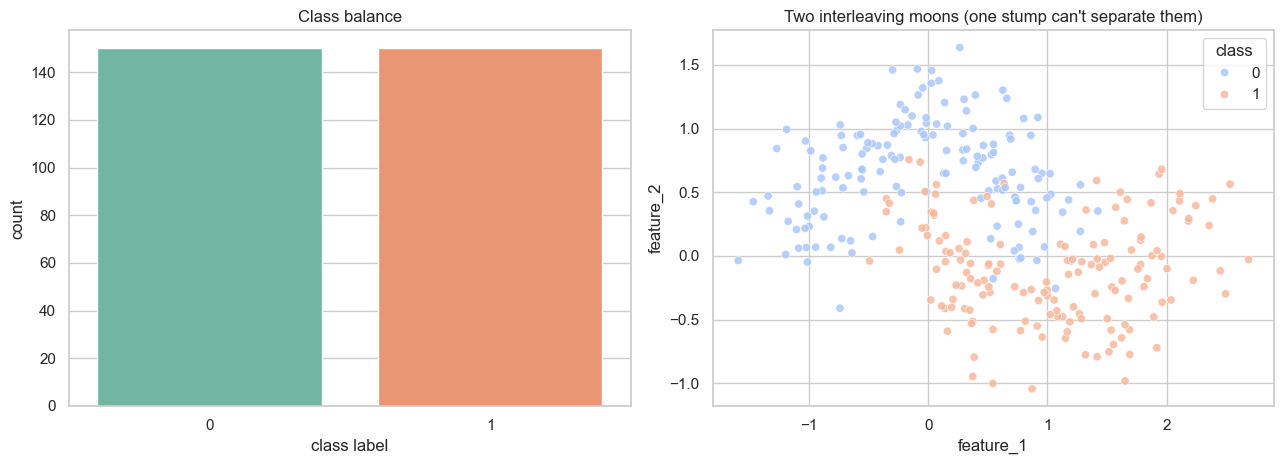

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.countplot(x="label", data=df, ax=axes[0], hue="label", palette="Set2", legend=False)
axes[0].set_title("Class balance"); axes[0].set_xlabel("class label"); axes[0].set_ylabel("count")
sns.scatterplot(data=df, x="feature_1", y="feature_2", hue="label",
                palette="coolwarm", alpha=0.85, ax=axes[1])
axes[1].set_title("Two interleaving moons (one stump can't separate them)")
axes[1].legend(title="class")
plt.tight_layout(); plt.show()


**Key insight:** the crescents are **not linearly separable**, so any single axis-aligned stump will be badly wrong on a large chunk of points — a **weak** learner. Boosting's promise is to **stack** these weak cuts into a strong, curved boundary. Classes are balanced, so **accuracy** is a fair headline metric.


## 8. Train the model

We boost **50 stumps**. After fitting we peek at the first few rounds' **errors** and **$\alpha$** values — early stumps are weak (error near 0.5, small $\alpha$), and later ones specialise.


In [8]:
ada = AdaBoost(n_estimators=50).fit(X_train, y_train)

test_pred = ada.predict(X_test)
print(f"Rounds: {len(ada.stumps)}")
print("First 6 weighted errors:", np.round(ada.estimator_errors_[:6], 3))
print("First 6 alphas:         ", np.round(ada.estimator_weights_[:6], 3))
print(f"Test accuracy: {accuracy(y_test, test_pred):.3f}")


Rounds: 50
First 6 weighted errors: [0.164 0.241 0.214 0.287 0.334 0.309]
First 6 alphas:          [0.813 0.574 0.651 0.455 0.346 0.402]
Test accuracy: 0.893


**What just happened:** `fit` ran 50 boosting rounds. Notice the **weighted errors hover near 0.5** (each stump is only slightly better than chance on the reweighted data) yet the ensemble is strong — that is boosting's paradox: **many weak, focused learners add up to an accurate one**. Each stump's $\alpha$ reflects how much it earned a vote.


## 9. Evaluate the model

**How to read these numbers:**
- **Accuracy** — overall fraction correct; fair here because classes are balanced.
- **Precision / Recall / F1** — macro-averaged across classes.

Then the **learning curve**: AdaBoost is genuinely iterative, so we can plot the **training error as rounds accumulate** — it should fall (often to 0), the hallmark of boosting driving down bias.


In [9]:
acc = accuracy(y_test, test_pred)
prec, rec, f1, per_class = precision_recall_f1(y_test, test_pred)
print(f"Accuracy:        {acc:.3f}")
print(f"Macro precision: {prec:.3f}")
print(f"Macro recall:    {rec:.3f}")
print(f"Macro F1:        {f1:.3f}\n")
display(per_class)


Accuracy:        0.893
Macro precision: 0.893
Macro recall:    0.893
Macro F1:        0.893



,precision,recall,f1
class 0,0.895,0.895,0.895
class 1,0.892,0.892,0.892


### Learning curve — train & test error per round

We track the ensemble's **training error** (recorded during `fit`) and compute the **test error** using the first $k$ stumps at each round. Training error marches down; test error drops then flattens.


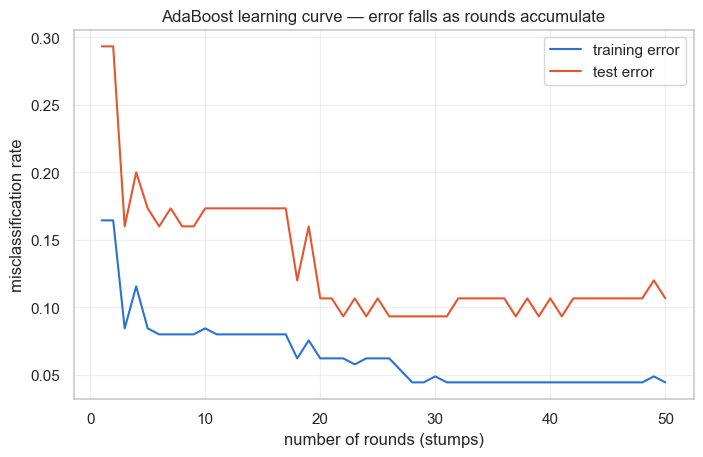

Training error after 50 rounds: 0.044
Test error after 50 rounds:     0.107


In [10]:
rounds = range(1, len(ada.stumps) + 1)
test_err = [np.mean(ada.predict(X_test, n=k) != y_test) for k in rounds]

plt.figure(figsize=(8, 4.8))
plt.plot(list(rounds), ada.train_errors_, "-", color="#2a72d4", label="training error")
plt.plot(list(rounds), test_err, "-", color="#e4572e", label="test error")
plt.xlabel("number of rounds (stumps)"); plt.ylabel("misclassification rate")
plt.title("AdaBoost learning curve — error falls as rounds accumulate")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print(f"Training error after {len(ada.stumps)} rounds: {ada.train_errors_[-1]:.3f}")
print(f"Test error after {len(ada.stumps)} rounds:     {test_err[-1]:.3f}")


**Key insight:** the blue **training error** falls steadily — each round fixes some of the previous mistakes, so bias drops. The red **test error** falls too, then **plateaus**. AdaBoost is famously resistant to overfitting for a while (it keeps improving the *margin* even after training error hits 0), but on **noisy** data too many rounds can eventually start to overfit — we make that visible in Section 11.


## 10. Visualising results

Numbers tell us *how well*; charts tell us *how*. AdaBoost's signature picture is the **sample reweighting** across rounds, followed by the strong **combined boundary**.

### Sample reweighting across the first rounds
Dot **size = current weight**. Watch the misclassified points swell round to round, and each round's stump (black line) attack the heavy region.


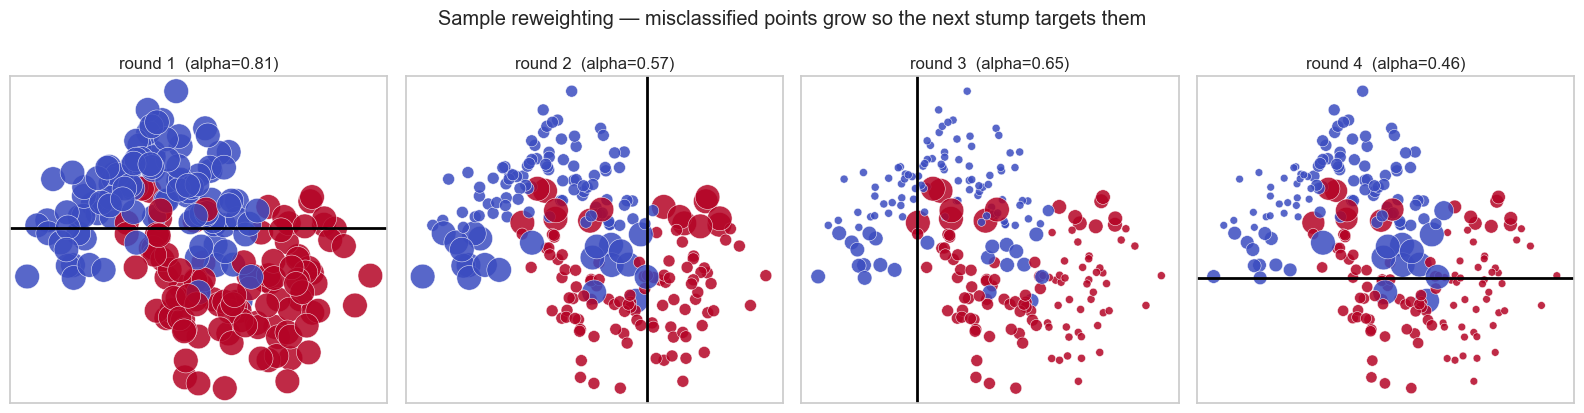

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, r in zip(axes, [0, 1, 2, 3]):
    w_r = ada.sample_weight_history_[r]
    stump = ada.stumps[r]
    sizes = 15 + w_r / w_r.max() * 300
    ax.scatter(X_train[:, 0], X_train[:, 1], s=sizes, c=y_train, cmap="coolwarm",
               edgecolor="white", linewidth=0.4, alpha=0.85)
    if stump.feature_idx == 0:
        ax.axvline(stump.threshold, color="black", lw=2)
    else:
        ax.axhline(stump.threshold, color="black", lw=2)
    ax.set_title(f"round {r+1}  (alpha={ada.estimator_weights_[r]:.2f})")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Sample reweighting — misclassified points grow so the next stump targets them")
plt.tight_layout(); plt.show()


**Key insight:** each panel's **big dots** are the points the ensemble is currently getting wrong; their weight has been pumped up so the next stump is *forced* to address them. The stump's line shifts to cut through the heavy region. This adaptive focus — "spend effort where you're failing" — is exactly why it's called **Ada**ptive **Boost**ing.

### The combined boundary
Fifty weak axis-aligned stumps, weighted-voted, produce a **strong, curved** boundary.


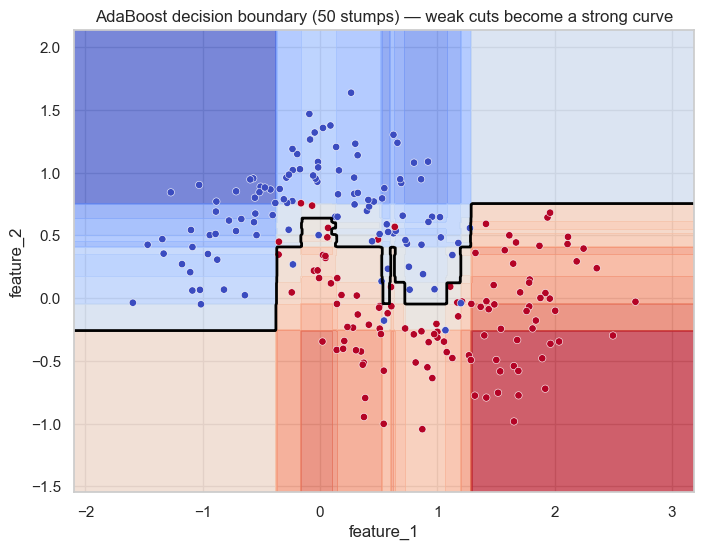

In [12]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = ada.decision_function(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=25, cmap="coolwarm", alpha=0.7)
plt.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
            edgecolor="white", s=28, linewidth=0.4)
plt.title("AdaBoost decision boundary (50 stumps) — weak cuts become a strong curve")
plt.xlabel("feature_1"); plt.ylabel("feature_2")
plt.show()


**Key insight:** no single stump could bend around the moons, but their **weighted vote** does — the black `score = 0` contour follows the crescents. The colour shows the **margin** (how confident the vote is); points far from the boundary are voted for strongly by many stumps.

### Confusion matrix & ROC


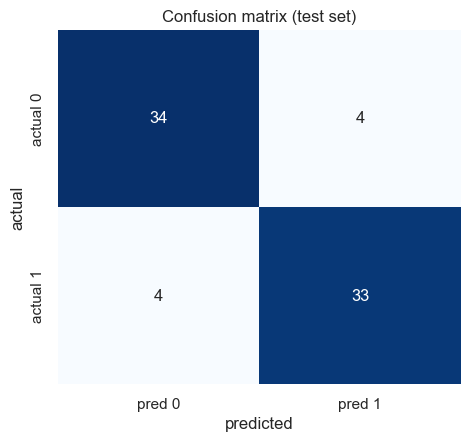

In [13]:
M, labels = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5.2, 4.6))
sns.heatmap(M, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=[f"pred {c}" for c in labels], yticklabels=[f"actual {c}" for c in labels])
plt.title("Confusion matrix (test set)"); plt.ylabel("actual"); plt.xlabel("predicted")
plt.show()


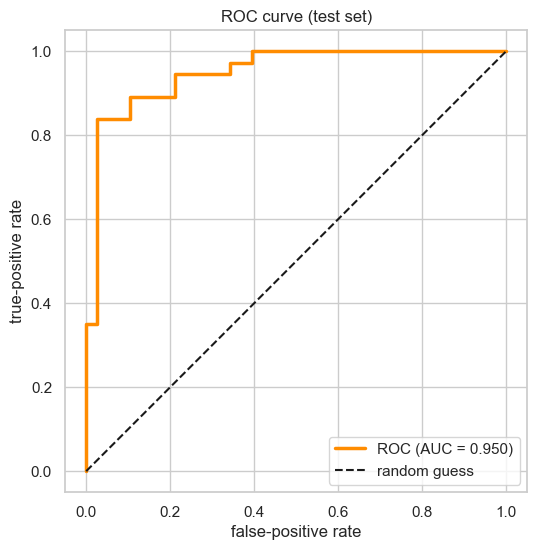

In [14]:
# ROC from the weighted-vote margin (decision_function)
scores_test = ada.decision_function(X_test)
pos = ada.classes_[1]
y_pos = (y_test == pos).astype(int)
order = np.argsort(-scores_test); y_sorted = y_pos[order]
P = y_pos.sum(); N = len(y_pos) - P
tpr = np.concatenate([[0], np.cumsum(y_sorted == 1) / P])
fpr = np.concatenate([[0], np.cumsum(y_sorted == 0) / N])
auc = float(np.sum(np.diff(fpr) * (tpr[:-1] + tpr[1:]) / 2))

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2.5, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="random guess")
plt.xlabel("false-positive rate"); plt.ylabel("true-positive rate")
plt.title("ROC curve (test set)"); plt.legend(loc="lower right"); plt.axis("square")
plt.show()


**Key insight:** the confusion matrix should be strongly **diagonal**, and the ROC hugs the **top-left** — the weighted-vote **margin** ranks points well, so AUC is high. Because the margin is a *sum of many $\alpha$-weighted votes*, it is fairly fine-grained (smoother than a single stump's two-valued output).


## 11. Animation — the boundary sharpens each round

AdaBoost "learns" by **adding stumps**. We reveal the boundary using the first $k$ stumps and step $k$ up. Press ▶ to watch a single crude cut grow into the curved moon boundary.


In [15]:
from matplotlib import animation
from IPython.display import HTML

ks = [1, 2, 3, 5, 8, 12, 20, 30, 40, 50]
maps = [ada.decision_function(grid, n=k).reshape(xx.shape) for k in ks]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
def draw_k(i):
    ax.clear()
    ax.contourf(xx, yy, maps[i], levels=25, cmap="coolwarm", alpha=0.7)
    ax.contour(xx, yy, maps[i], levels=[0], colors="black", linewidths=2)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
               edgecolor="white", s=24, linewidth=0.3)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_title(f"weighted vote of {ks[i]} stump(s)")
    ax.set_xlabel("feature_1"); ax.set_ylabel("feature_2")

boost_anim = animation.FuncAnimation(fig, draw_k, frames=len(ks), interval=650)
plt.close(fig)  # prevent a duplicate static figure
HTML(boost_anim.to_jshtml())


**What to notice:** **one** stump gives a single straight cut (very weak). Each added stump nudges the weighted vote, and by ~20–30 rounds the boundary **wraps around the crescents**. The strength emerges from the *combination*, not any individual stump.


### Bonus: interactive extras (play and drag)

The animation above is a pre-rendered video. Here are two **interactive** Plotly views you can explore live.

> **Why no 3-D loss surface here?** AdaBoost is a **sequential, additive** method (forward stagewise fitting of an exponential loss), not gradient descent over two parameters. The meaningful controls for a booster are **how many rounds** you run and **how the train/test error evolves** — so that's what these explore.

#### 1. Rounds explorer — drag the number of stumps
Drag the slider (or press ▶) to add stumps and watch the boundary sharpen from one crude cut into the moon shape.


In [16]:
# Interactive boundary vs number of rounds (Plotly heatmap frames + play + slider)
import plotly.graph_objects as go

gx = np.linspace(x_min, x_max, 110); gy = np.linspace(y_min, y_max, 110)
GX, GY = np.meshgrid(gx, gy); flat = np.c_[GX.ravel(), GY.ravel()]

k_list = [1, 2, 3, 5, 8, 12, 20, 30, 40, 50]
Zk = {k: ada.decision_function(flat, n=k).reshape(GX.shape) for k in k_list}

def heat(k):
    zz = Zk[k]; lim = np.abs(zz).max() + 1e-9
    return go.Heatmap(x=gx, y=gy, z=zz, colorscale="RdBu", zmin=-lim, zmax=lim,
                      opacity=0.75, showscale=False)

pts = go.Scatter(x=X_train[:, 0], y=X_train[:, 1], mode="markers",
                 marker=dict(color=y_train, colorscale="RdBu", size=6,
                             line=dict(color="white", width=0.5)), showlegend=False)

frames = [go.Frame(data=[heat(k), pts], name=str(k)) for k in k_list]
fig_b = go.Figure(data=[heat(k_list[0]), pts], frames=frames)
fig_b.update_layout(
    title=dict(text="AdaBoost boundary vs number of stumps  (weak -> strong)", x=0.5, xanchor="center"),
    xaxis_title="feature_1", yaxis_title="feature_2",
    template="plotly_white", width=760, height=560,
    updatemenus=[dict(type="buttons", x=0.0, y=1.15, showactive=False,
        buttons=[dict(label="Add stumps", method="animate",
                      args=[None, dict(frame=dict(duration=650, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="n_stumps = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(k),
                    args=[[str(k)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for k in k_list])],
)
fig_b.show()


**What to notice:** the first few stumps carve broad regions; later ones refine the crescents' edges. The colour is the **vote margin** — it deepens (more confident) as more stumps agree.

#### 2. Overfitting explorer — train vs test error over many rounds
Push the number of rounds high on this **noisy** data and watch the classic boosting behaviour: **training error drives toward 0**, while **test error** bottoms out and can then **creep up** — boosting's version of a knob that eventually degrades.


In [17]:
# Interactive: train vs test error as rounds grow (with a moving marker)
import plotly.graph_objects as go

big = AdaBoost(n_estimators=120).fit(X_train, y_train)
rounds_axis = list(range(1, 121))
tr_err = big.train_errors_
te_err = [float(np.mean(big.predict(X_test, n=k) != y_test)) for k in rounds_axis]

base = [go.Scatter(x=rounds_axis, y=tr_err, mode="lines", name="training error", line=dict(color="#2a72d4")),
        go.Scatter(x=rounds_axis, y=te_err, mode="lines", name="test error", line=dict(color="#e4572e"))]
marks = list(range(5, 121, 5))
frames = [go.Frame(data=base + [go.Scatter(x=[k, k], y=[0, max(max(tr_err), max(te_err)) * 1.1],
                                           mode="lines", line=dict(color="green", dash="dash"),
                                           showlegend=False)], name=str(k)) for k in marks]
fig_o = go.Figure(data=base + [go.Scatter(x=[marks[0], marks[0]], y=[0, 0.5], mode="lines",
                                          line=dict(color="green", dash="dash"), showlegend=False)],
                  frames=frames)
fig_o.update_layout(
    title=dict(text="Boosting rounds — training error -> 0, test error bottoms then can rise", x=0.5, xanchor="center"),
    xaxis_title="number of rounds", yaxis_title="misclassification rate",
    template="plotly_white", width=780, height=470,
    updatemenus=[dict(type="buttons", x=0.0, y=1.16, showactive=False,
        buttons=[dict(label="Add rounds", method="animate",
                      args=[None, dict(frame=dict(duration=250, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, currentvalue=dict(prefix="rounds = "), x=0.1, len=0.8,
        steps=[dict(method="animate", label=str(k),
                    args=[[str(k)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for k in marks])],
)
fig_o.show()


**What to notice:** the **blue training error** slides toward **0** — boosting keeps fixing training mistakes. The **red test error** drops fast, bottoms out, and on this noisy data eventually **stops improving (and may drift up)**: past a point, extra rounds fit noise. This is why `n_estimators` (often with a small `learning_rate`) is tuned with a validation curve.

**More creative ideas you could add** (each just a few lines):
- a **learning-rate explorer** (shrinkage): smaller steps + more rounds often generalise better;
- a **margin distribution** plot showing boosting keeps widening margins after train error hits 0;
- a **weak-vs-strong** panel: accuracy of one stump vs the full ensemble;
- a **weighted-error per round** trace showing each stump hovering near 0.5.

> **Note for GitHub:** these Plotly interactives render in VS Code/Jupyter but **not** in GitHub's static `.ipynb` preview. Re-run the notebook locally (or export static images) to see them.


## 12. Bonus example — a real dataset (breast cancer)

The moons were 2-D. Let's point the **exact same from-scratch AdaBoost** at the real medical dataset from the original `adaboost.py` script.

scikit-learn's **breast cancer** dataset: **569 patients**, **30 numeric features**, target **malignant (0)** vs **benign (1)**. Boosting stumps on this data is a strong, interpretable baseline — and needs **no scaling** (stumps are threshold tests).


In [18]:
bc = load_breast_cancer()
Xc, yc = bc.data, bc.target
feat_names = list(bc.feature_names)

df_c = pd.DataFrame(Xc, columns=feat_names); df_c["target"] = yc
print("Shape (rows, cols):", df_c.shape)
print("Missing values:", df_c.isna().sum().sum())
print("Duplicate rows:", df_c.duplicated().sum())
print("Class counts (0=malignant, 1=benign):")
print(df_c["target"].value_counts())
display(df_c.iloc[:, :6].head())


Shape (rows, cols): (569, 31)
Missing values: 0
Duplicate rows: 0
Class counts (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280


### Train, evaluate, and read the learning curve


Test accuracy: 0.965
Macro F1:      0.961



,precision,recall,f1
class 0,1.000,0.905,0.950
class 1,0.947,1.000,0.973


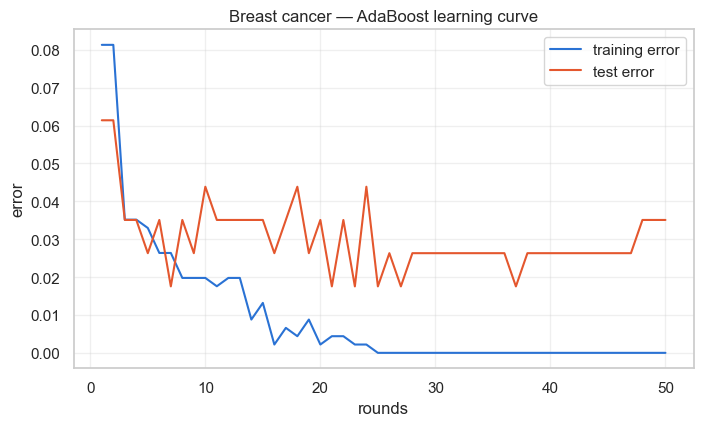

In [19]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=1234, stratify=yc
)

ada_c = AdaBoost(n_estimators=50).fit(Xc_train, yc_train)
pred_c = ada_c.predict(Xc_test)

acc_c = accuracy(yc_test, pred_c)
prec_c, rec_c, f1_c, per_class_c = precision_recall_f1(yc_test, pred_c)
print(f"Test accuracy: {acc_c:.3f}")
print(f"Macro F1:      {f1_c:.3f}\n")
display(per_class_c)

rounds_c = range(1, len(ada_c.stumps) + 1)
test_err_c = [np.mean(ada_c.predict(Xc_test, n=k) != yc_test) for k in rounds_c]
plt.figure(figsize=(8, 4.4))
plt.plot(list(rounds_c), ada_c.train_errors_, color="#2a72d4", label="training error")
plt.plot(list(rounds_c), test_err_c, color="#e4572e", label="test error")
plt.xlabel("rounds"); plt.ylabel("error"); plt.title("Breast cancer — AdaBoost learning curve")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


**What just happened:** on real 30-feature data, boosting 50 stumps reaches strong accuracy. The learning curve shows the training error dropping toward 0 while the test error settles — a well-behaved booster. No scaling was applied (stumps are scale-invariant).


In [20]:
# Interactive confusion matrix (Plotly) with metrics annotated
import plotly.graph_objects as go

Mc, labels_c = confusion_matrix(yc_test, pred_c)
fig_cm = go.Figure(go.Heatmap(
    z=Mc, x=["pred malignant (0)", "pred benign (1)"],
    y=["actual malignant (0)", "actual benign (1)"],
    colorscale="Blues", showscale=True, colorbar=dict(title="count"),
    text=Mc, texttemplate="%{text}", textfont=dict(size=16)))
fig_cm.add_annotation(x=0.5, y=1.16, xref="paper", yref="paper", showarrow=False,
    text=f"Accuracy {acc_c:.3f}  -  Precision {prec_c:.3f}  -  Recall {rec_c:.3f}  -  Macro F1 {f1_c:.3f}",
    font=dict(size=12, color="#444"))
fig_cm.update_layout(
    title=dict(text="Breast cancer — AdaBoost confusion matrix (test set)", x=0.5, xanchor="center"),
    template="plotly_white", width=620, height=560, yaxis=dict(autorange="reversed"))
fig_cm.show()


**Key insight:** the matrix is strongly **diagonal**. In screening you'd still watch **false negatives** most; the weighted-vote margin (`decision_function`) lets you shift the threshold to trade a few false alarms for fewer misses.


In [21]:
# Feature usage importance = total alpha of stumps that split on each feature (Plotly bar)
import plotly.graph_objects as go

importance = np.zeros(Xc.shape[1])
for stump, alpha in zip(ada_c.stumps, ada_c.estimator_weights_):
    importance[stump.feature_idx] += alpha
importance = importance / importance.sum()

imp = pd.Series(importance, index=feat_names).sort_values()
top = imp[imp > 0].tail(12)

fig_imp = go.Figure()
fig_imp.add_bar(x=top.values, y=list(top.index), orientation="h",
                marker=dict(color="#8250c4", line=dict(color="white", width=0.5)),
                text=[f"{v:.2f}" for v in top.values], textposition="outside", cliponaxis=False,
                hovertemplate="%{y}: importance = %{x:.2f}<extra></extra>", showlegend=False)
fig_imp.update_layout(
    title=dict(text="Which features did the boosted stumps rely on?<br>"
                    "<sup>Breast cancer — total alpha weight per feature (normalised)</sup>",
               x=0.5, xanchor="center"),
    xaxis_title="summed vote weight (alpha) of stumps using the feature",
    template="plotly_white", width=840, height=560, bargap=0.3, margin=dict(l=200, t=90, r=60, b=60))
fig_imp.show()


**Key insight:** each stump splits on **one** feature, so summing the $\alpha$ of all stumps that used a feature gives a natural **importance** — the features boosting leaned on most to correct mistakes. The top ones are the familiar `worst`-suffixed size/texture measures, matching the other models and clinical intuition. Boosting reached that ranking by *repeatedly attacking the hardest cases*.


## 13. Key takeaways

- **AdaBoost** turns a **weak learner** (a one-split stump) into a strong classifier by **boosting**: train sequentially, each round focusing on the previous mistakes.
- It **reweights** the data (up-weight errors) and gives each stump a vote **$\alpha=\tfrac12\ln\frac{1-\varepsilon}{\varepsilon}$**; the final prediction is the **weighted vote's sign**.
- **Boosting reduces bias** (weak → strong); **bagging (random forests) reduces variance** — the two great ensemble strategies.
- It is **scale-invariant** (stumps are threshold tests) and yields a natural **feature importance** from summed $\alpha$.
- It drives **training error toward 0** and keeps improving **margins**, but on **noisy** data too many rounds can overfit — tune `n_estimators` (and `learning_rate`) with a validation curve.
- **Real data is messier**, yet boosted trees are among the **strongest tabular models** — the direct ancestors of XGBoost/LightGBM.


## 14. Common mistakes and troubleshooting

| Problem | Cause | Fix |
|--------|-------|-----|
| Test error rises with more rounds | Overfitting **noise** | Fewer rounds, smaller `learning_rate`, or early stopping |
| Every stump has error ≈ 0.5, no progress | Data not learnable by 1-feature cuts | Use deeper base learners or add features |
| One noisy point dominates | Its weight explodes each round | Cap weights / clean outliers / use a robust loss |
| `alpha` is huge or negative | Error near 0 or above 0.5 | The `EPS` guard + polarity flip handle this |
| Slow training | Threshold scan over many features | Sort once, subsample thresholds, or use histograms |
| Wasted effort scaling features | Stumps are **scale-invariant** | Skip `StandardScaler` |
| Only binary works | This is discrete two-class AdaBoost | Use SAMME / one-vs-rest for multi-class |


## 15. Exercises

1. **Rounds.** Plot test error vs `n_estimators` (1 → 200) on breast cancer. Where does it bottom out?
2. **Learning rate.** Add shrinkage (`learning_rate=0.1`) with more rounds — does it generalise better?
3. **Weak vs strong.** Compare a single stump's accuracy to the full ensemble on the moons.
4. **Noise.** Raise `make_moons(noise=0.4)` and watch the overfitting explorer — when does test error rise?
5. **Margins.** Plot the distribution of `decision_function` values for correct vs incorrect points.
6. **Compare.** Fit scikit-learn's `AdaBoostClassifier` and compare accuracy and estimator weights.
7. **Boosting vs bagging.** Compare AdaBoost to your random forest on the same data — which wins, and why (bias vs variance)?


## 16. Next steps and improvements

- **Compare with scikit-learn's `AdaBoostClassifier`** to sanity-check the from-scratch result.
- **Deeper base learners:** boost depth-2/3 trees instead of stumps for more expressive weak learners.
- **Gradient boosting:** generalise from exponential loss to *any* differentiable loss — the idea behind **XGBoost, LightGBM, CatBoost**, the champions of tabular ML.
- **Shrinkage + subsampling:** small `learning_rate` with many rounds, plus row/column subsampling (stochastic boosting), usually generalises best.
- **Multi-class:** implement **SAMME**/**SAMME.R** to go beyond two classes.

---
*Built from the `adaboost.py` "ML from scratch" implementation. The weighted stump search, $\alpha$ update, exponential reweighting, and weighted-vote prediction are preserved; a `classes_` label mapping, midpoint thresholds, per-round histories (errors, $\alpha$, training error, sample weights), a `decision_function`, an optional `learning_rate`, type hints/docstrings, the tutorial structure, EDA, the reweighting and boundary visuals, animations, and the real-data walkthrough were added for self-study.*
